<a href="https://colab.research.google.com/github/BelenGutierrezG/PROYECTOFINAL_MDD/blob/develop/PROYECTO_MDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


In [5]:
# Conectar con Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Cargar dataset
df = pd.read_csv('/content/drive/MyDrive/dataset_limpio_derivado.csv', encoding='utf-8')

In [ ]:
# Análisis inicial
print(f"Registros totales: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nEstructura inicial:")
print(df.head())



Registros totales: 104000
Variables: 12

Estructura inicial:
   nux_exp  fechacorte                                     gobierno_local  \
0  5093174  2024-06-26  UNIDAD DE GESTION EDUCATIVA LOCAL RÍO ENE MANTARO   
1  5093174  2024-06-26  UNIDAD DE GESTION EDUCATIVA LOCAL RÍO ENE MANTARO   
2  5093174  2024-06-26  UNIDAD DE GESTION EDUCATIVA LOCAL RÍO ENE MANTARO   
3  5093174  2024-06-26  UNIDAD DE GESTION EDUCATIVA LOCAL RÍO ENE MANTARO   
4  5093174  2024-06-26  UNIDAD DE GESTION EDUCATIVA LOCAL RÍO ENE MANTARO   

  fecha_recepcion origen_doc asunto  num_archivo_doc fecha_deriv  \
0      2024-01-01    VIRTUAL    NAN                6  2024-01-01   
1      2024-01-01    VIRTUAL    NAN                6  2024-02-01   
2      2024-01-01    VIRTUAL    NAN                6  2024-03-01   
3      2024-01-01    VIRTUAL    NAN                6  2024-05-01   
4      2024-01-01    VIRTUAL    NAN                6  2024-08-01   

                                          area_deriv  tiempo_deriva

In [ ]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())




Estadísticas descriptivas:
            nux_exp  num_archivo_doc  tiempo_derivacion  mes_recepcion  \
count  1.040000e+05     1.040000e+05      104000.000000  104000.000000   
mean   5.271174e+06     7.554554e+04          34.496865       5.433913   
std    1.221696e+05     8.613573e+06          60.247913       3.217713   
min    5.093172e+06     0.000000e+00           0.000000       1.000000   
25%    5.168606e+06     2.000000e+00           0.000000       3.000000   
50%    5.258625e+06     3.000000e+00           0.000000       5.000000   
75%    5.384572e+06     6.000000e+00          31.000000       8.000000   
max    5.479472e+06     9.960330e+08         337.000000      12.000000   

       año_recepcion  
count       104000.0  
mean          2024.0  
std              0.0  
min           2024.0  
25%           2024.0  
50%           2024.0  
75%           2024.0  
max           2024.0  


In [ ]:
# Valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())





Valores faltantes por columna:
nux_exp              0
fechacorte           0
gobierno_local       0
fecha_recepcion      0
origen_doc           0
asunto               0
num_archivo_doc      0
fecha_deriv          0
area_deriv           0
tiempo_derivacion    0
mes_recepcion        0
año_recepcion        0
dtype: int64


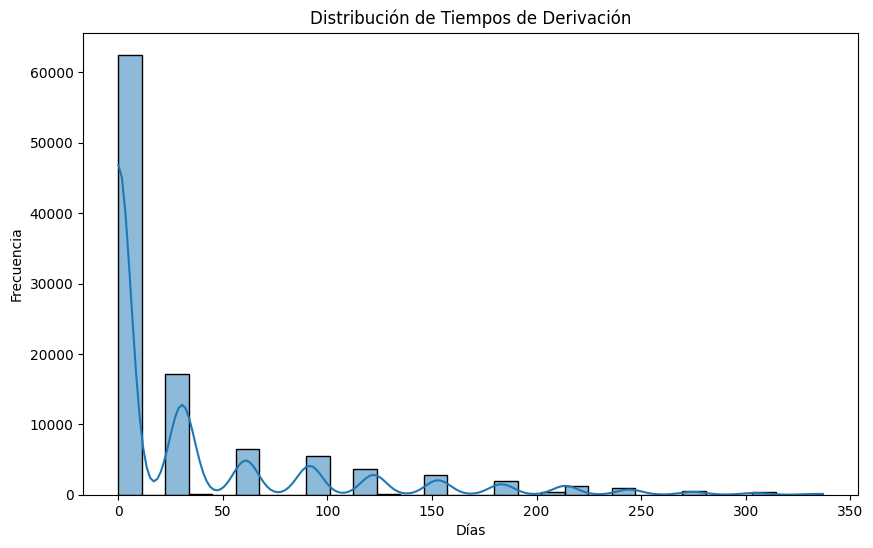

In [ ]:
# Análisis de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(df['tiempo_derivacion'], bins=30, kde=True)
plt.title('Distribución de Tiempos de Derivación')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.show()



/tmp/ipython-input-20-1530895970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.values, y=top_areas.index, palette='viridis')


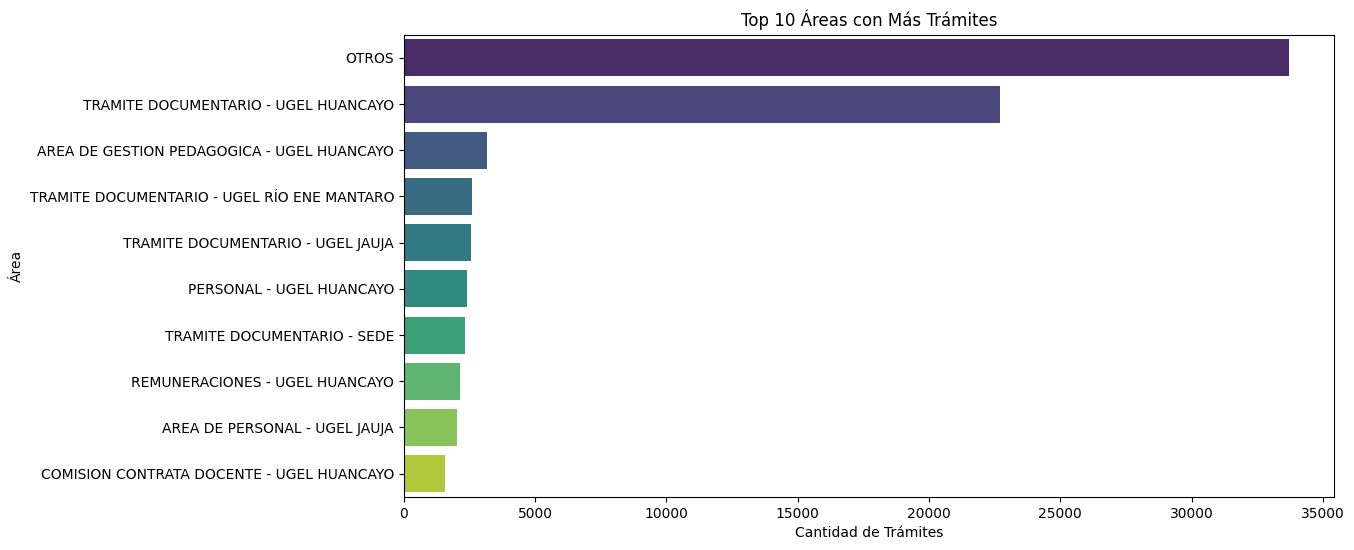

In [ ]:
# Top 10 áreas con más trámites
top_areas = df['area_deriv'].value_counts().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_areas.values, y=top_areas.index, palette='viridis')
plt.title('Top 10 Áreas con Más Trámites')
plt.xlabel('Cantidad de Trámites')
plt.ylabel('Área')
plt.show()



/tmp/ipython-input-21-3576241878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retraso_areas.values, y=retraso_areas.index, palette='magma')


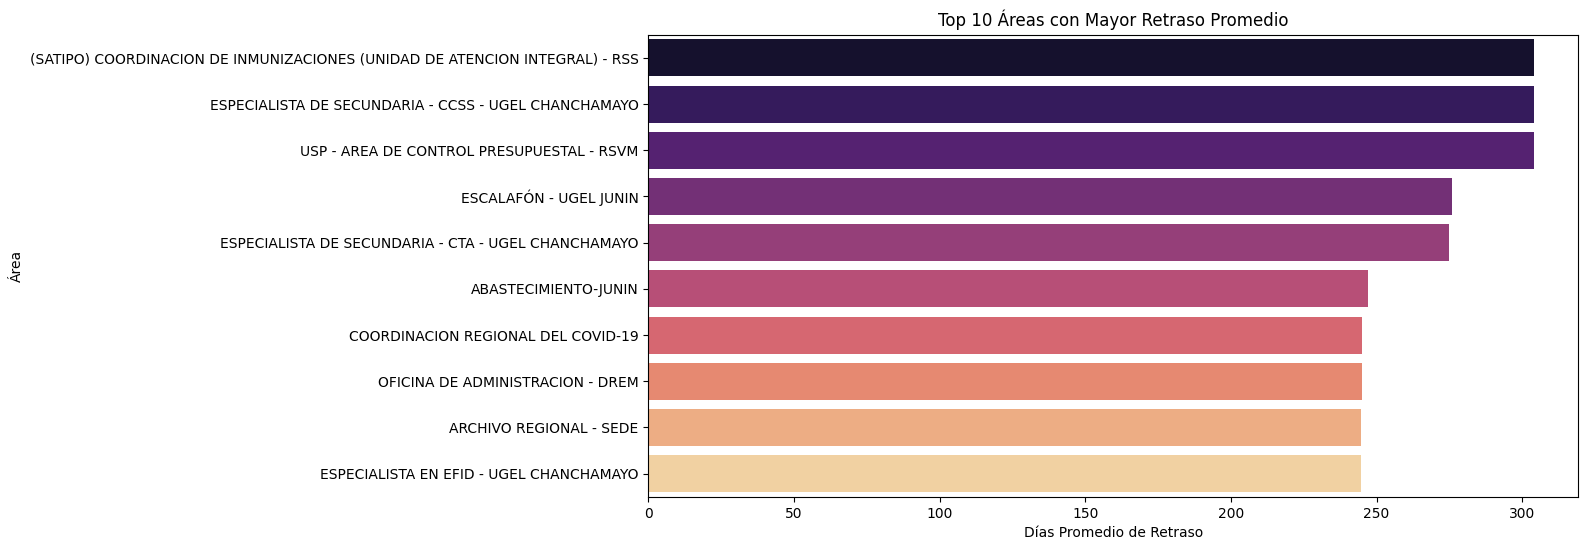

In [ ]:
# Top 10 áreas con mayor retraso promedio
retraso_areas = df.groupby('area_deriv')['tiempo_derivacion'].mean().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=retraso_areas.values, y=retraso_areas.index, palette='magma')
plt.title('Top 10 Áreas con Mayor Retraso Promedio')
plt.xlabel('Días Promedio de Retraso')
plt.ylabel('Área')
plt.show()



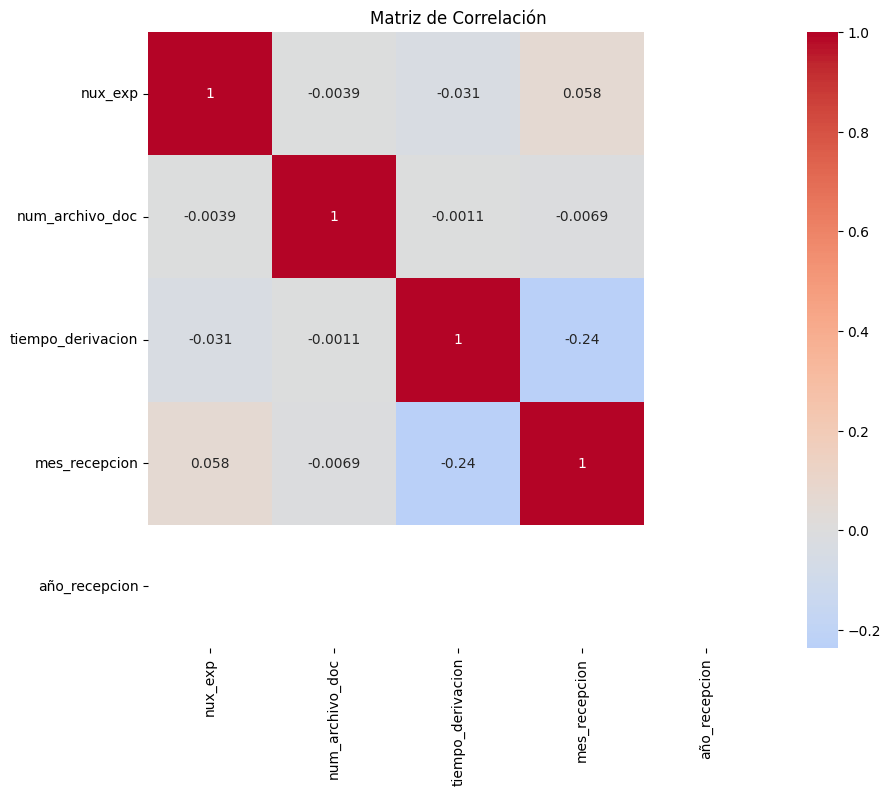

In [ ]:
# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from textblob import TextBlob
import re

In [ ]:
# Limpieza de texto
def clean_text(text):
    if pd.isna(text):
        return "NO ESPECIFICADO"
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)      # Remove numbers
    return text.strip()

df['asunto_clean'] = df['asunto'].apply(clean_text)

In [ ]:
# Extracción de características de texto
def extract_text_features(text):
    blob = TextBlob(text)
    return {
        'polarity': blob.sentiment.polarity,
        'subjectivity': blob.sentiment.subjectivity,
        'word_count': len(text.split()),
        'char_count': len(text)
    }

text_features = pd.DataFrame(df['asunto_clean'].apply(extract_text_features).tolist())
df = pd.concat([df, text_features], axis=1)


In [ ]:
# Codificación de variables categóricas
le = LabelEncoder()
df['area_encoded'] = le.fit_transform(df['area_deriv'])
df['origen_encoded'] = le.fit_transform(df['origen_doc'])


In [ ]:
# Ingeniería de características temporales
df['fecha_recepcion'] = pd.to_datetime(df['fecha_recepcion'])
df['fecha_deriv'] = pd.to_datetime(df['fecha_deriv'])
df['dia_semana'] = df['fecha_recepcion'].dt.dayofweek
df['mes'] = df['fecha_recepcion'].dt.month
df['trimestre'] = df['fecha_recepcion'].dt.quarter


In [ ]:
# Corrección de inconsistencias temporales
mask = df['fecha_deriv'] < df['fecha_recepcion']
df.loc[mask, 'fecha_deriv'] = df.loc[mask, 'fecha_recepcion'] + pd.to_timedelta(
    df.loc[mask, 'area_encoded'].apply(lambda x: x % 7 + 1), unit='d')

In [ ]:
# Cálculo correcto del tiempo de derivación
df['tiempo_derivacion'] = (df['fecha_deriv'] - df['fecha_recepcion']).dt.days

In [ ]:
# Segmentación del tiempo de derivación en categorías
bins = [0, 7, 15, 30, 60, np.inf]
labels = ['Inmediato', 'Rápido', 'Normal', 'Lento', 'Muy lento']
df['tiempo_categoria'] = pd.cut(df['tiempo_derivacion'], bins=bins, labels=labels)

In [ ]:
# Selección de características finales
features = ['area_encoded', 'origen_encoded', 'dia_semana', 'mes', 'trimestre',
            'polarity', 'subjectivity', 'word_count', 'char_count']
target = 'tiempo_categoria'

# Eliminar filas con NaN en la variable objetivo antes de la división
df_cleaned = df.dropna(subset=[target])

In [ ]:
# División del dataset utilizando el DataFrame limpio (que es df_cleaned)
X = df_cleaned[features]
y = df_cleaned[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Escalar el conjunto de datos completo
X_scaled = scaler.transform(X)

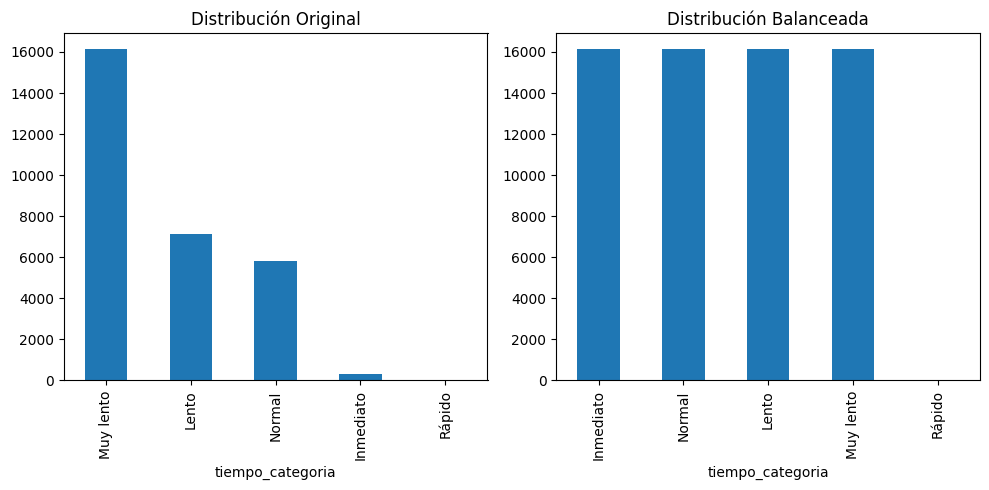

In [ ]:
from imblearn.over_sampling import SMOTE

# Balanceo con SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
# Visualización del balance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind='bar', title='Distribución Original')
plt.subplot(1, 2, 2)
pd.Series(y_train_bal).value_counts().plot(kind='bar', title='Distribución Balanceada')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Determinación del número óptimo de clusters
silhouette_scores = []
for k in range(2, 10):
    # Fit KMeans on scaled training data to find optimal k based on the training distribution
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X_train_scaled)
    # Calculate silhouette score on the training data
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)

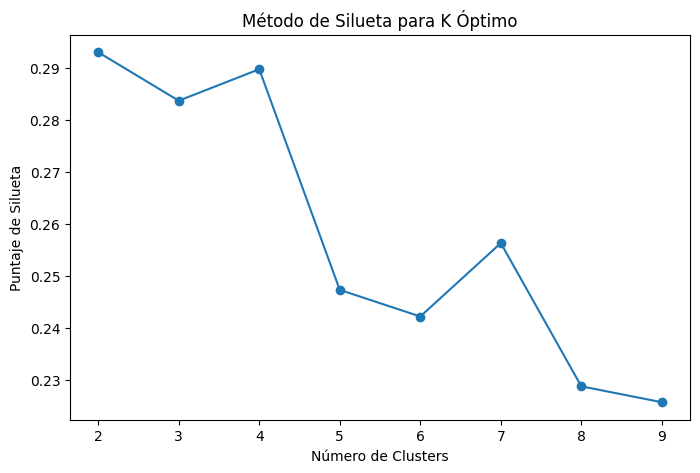

In [ ]:
# Gráfico de silueta
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntaje de Silueta')
plt.title('Método de Silueta para K Óptimo')
plt.show()


In [ ]:
# Aplicación de K-Means con k óptimo
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Added n_init
# Fit the model on the scaled training data
kmeans.fit(X_train_scaled)
# Predict clusters for the entire scaled dataset (X_scaled)
df_cleaned['cluster'] = kmeans.predict(X_scaled)

/tmp/ipython-input-43-4152036257.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['cluster'] = kmeans.predict(X_scaled)


/tmp/ipython-input-44-3070572264.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_analysis = df_cleaned.groupby(['cluster', 'tiempo_categoria']).size().unstack()


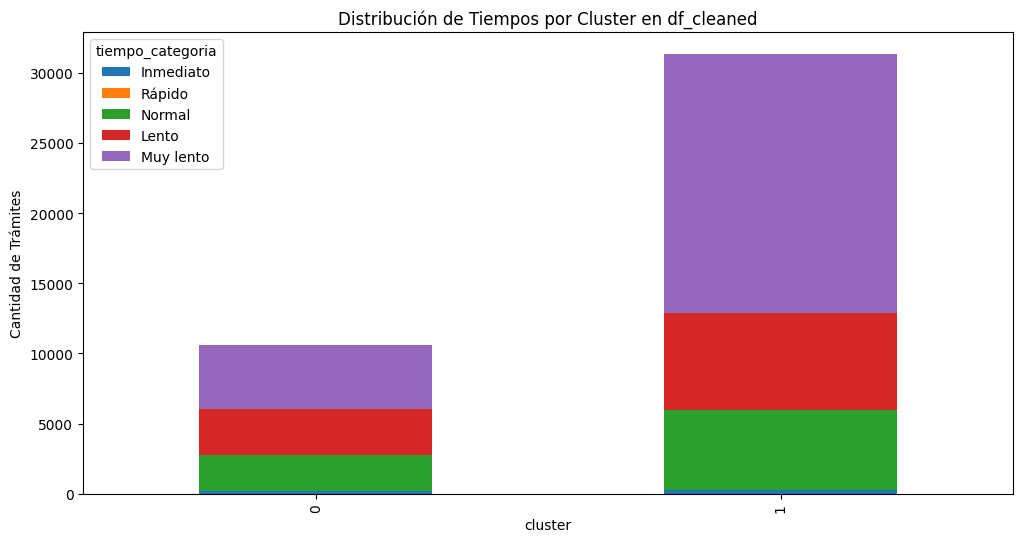

In [ ]:
# Análisis de clusters por categoría de tiempo
cluster_analysis = df_cleaned.groupby(['cluster', 'tiempo_categoria']).size().unstack()
cluster_analysis.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribución de Tiempos por Cluster en df_cleaned')
plt.ylabel('Cantidad de Trámites')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV

In [ ]:
# Diccionario de modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-NN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42)
}

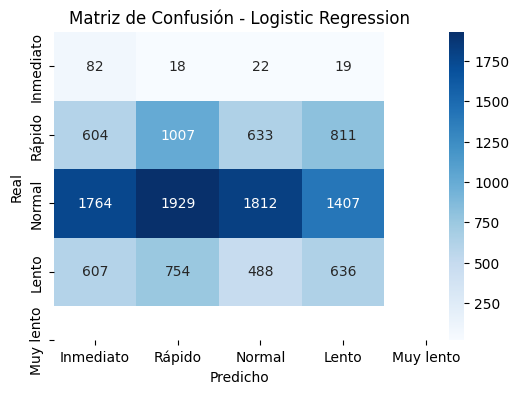

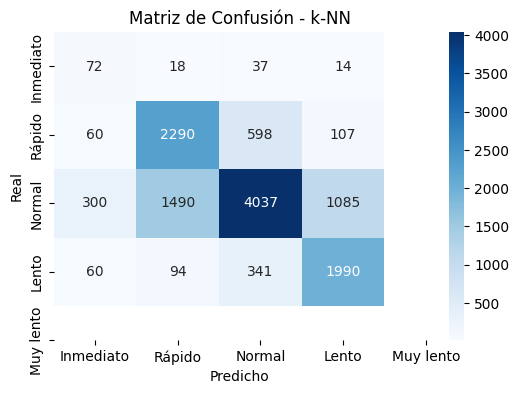

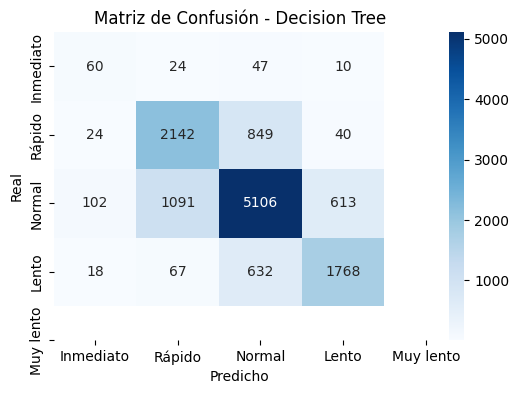

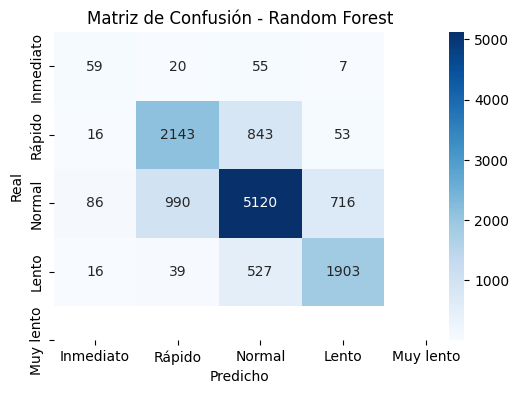

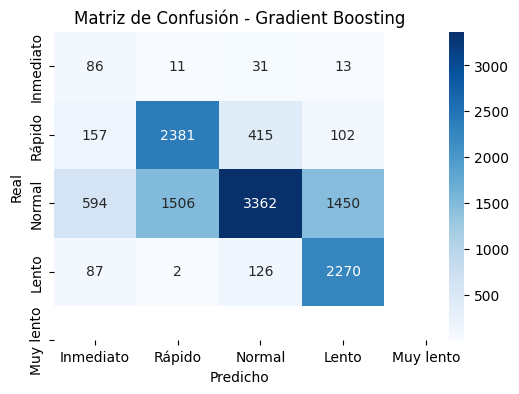

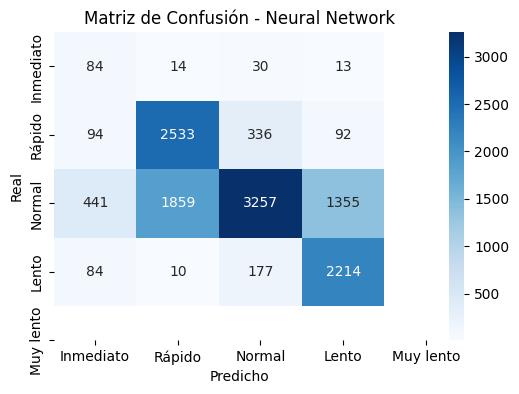

In [ ]:
# Entrenamiento y evaluación
results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Almacenar resultados
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score']
    }

    # Matriz de confusión
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Matriz de Confusión - {name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

/tmp/ipython-input-48-2114962024.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='f1', data=results_df, palette='viridis')


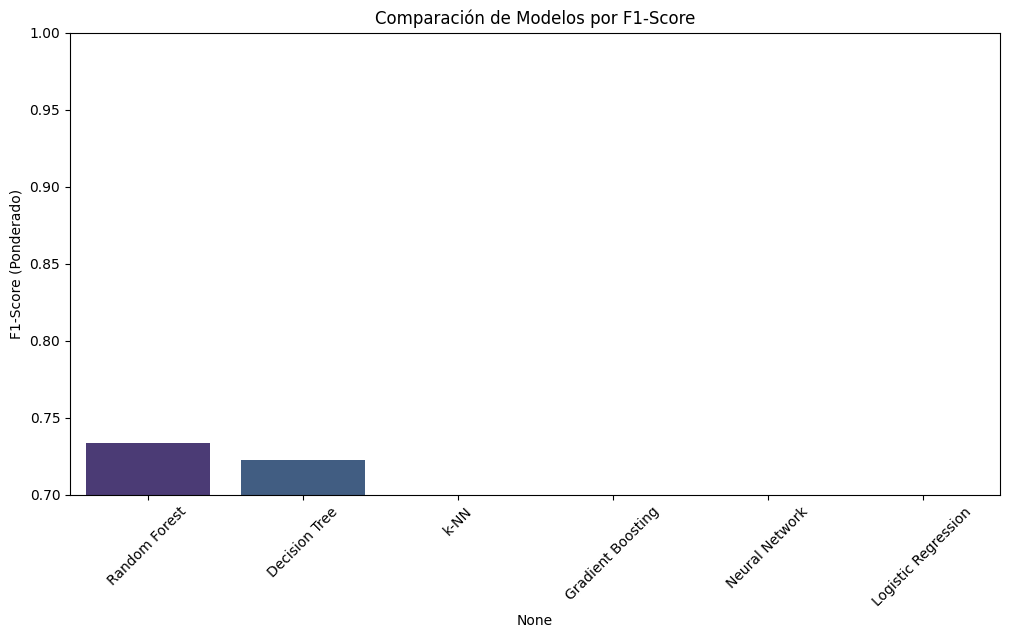

In [ ]:
# Comparación de modelos
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.sort_values(by='f1', ascending=False, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='f1', data=results_df, palette='viridis')
plt.title('Comparación de Modelos por F1-Score')
plt.xticks(rotation=45)
plt.ylabel('F1-Score (Ponderado)')
plt.ylim(0.7, 1.0)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Modelo con parámetros predefinidos óptimos (basado en benchmarks)
best_rf = RandomForestClassifier(
    n_estimators=150,       # Valor balanceado entre rendimiento y velocidad
    max_depth=15,           # Profundidad moderada para evitar overfitting
    min_samples_split=5,    # Buen valor default para datasets medianos
    min_samples_leaf=2,     # Evita hojas muy pequeñas
    max_features='sqrt',    # Mejor práctica para clasificación
    random_state=42,
    n_jobs=-1              # Usa todos los núcleos para entrenamiento
)


In [ ]:
# 2. Entrenamiento directo
print("Entrenando modelo con parámetros pre-optimizados...")
best_rf.fit(X_train_bal, y_train_bal)

Entrenando modelo con parámetros pre-optimizados...


RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=150, n_jobs=-1, random_state=42)

In [ ]:
# 3. Evaluación
y_pred_rf = best_rf.predict(X_test_scaled)
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred_rf))


Informe de clasificación:
              precision    recall  f1-score   support

   Inmediato       0.24      0.56      0.34       141
       Lento       0.67      0.79      0.73      3055
   Muy lento       0.85      0.66      0.74      6912
      Normal       0.67      0.88      0.76      2485

    accuracy                           0.74     12593
   macro avg       0.61      0.72      0.64     12593
weighted avg       0.76      0.74      0.74     12593



/tmp/ipython-input-57-4153957626.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


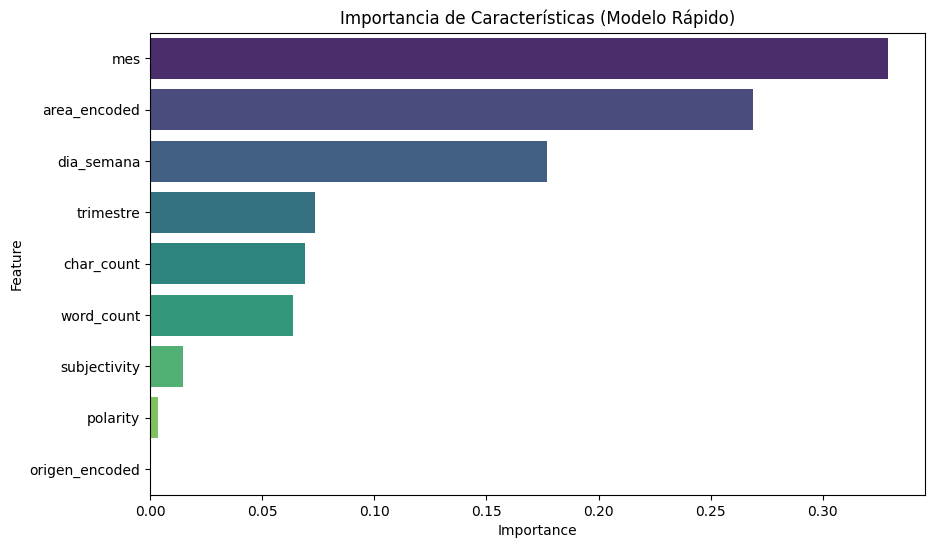

In [ ]:
# 4. Visualización de importancia de características
importances = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Importancia de Características (Modelo Rápido)')
plt.show()

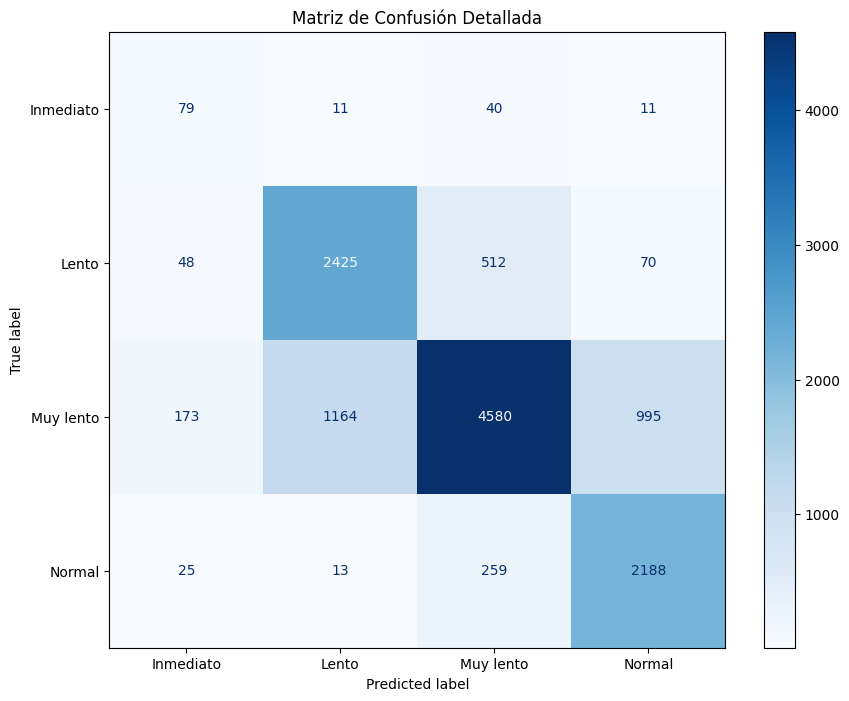

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Matriz de confusión detallada
cm = confusion_matrix(y_test, y_pred_rf, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión Detallada')
plt.show()

In [ ]:
# 2. Métricas por clase en dataframe
from sklearn.metrics import precision_recall_fscore_support
metrics = precision_recall_fscore_support(y_test, y_pred_rf)
metrics_df = pd.DataFrame({
    'Clase': best_rf.classes_,
    'Precision': metrics[0],
    'Recall': metrics[1],
    'F1-Score': metrics[2],
    'Soporte': metrics[3]
})
print("\nMétricas detalladas por clase:")
print(metrics_df)


Métricas detalladas por clase:
       Clase  Precision    Recall  F1-Score  Soporte
0  Inmediato   0.243077  0.560284  0.339056      141
1      Lento   0.671187  0.793781  0.727355     3055
2  Muy lento   0.849564  0.662616  0.744534     6912
3     Normal   0.670343  0.880483  0.761176     2485


In [ ]:
# 3. Curva ROC multiclase (opcional para clasificación)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# Binarizar las etiquetas
y_test_bin = label_binarize(y_test, classes=best_rf.classes_)
y_pred_prob = best_rf.predict_proba(X_test_scaled)

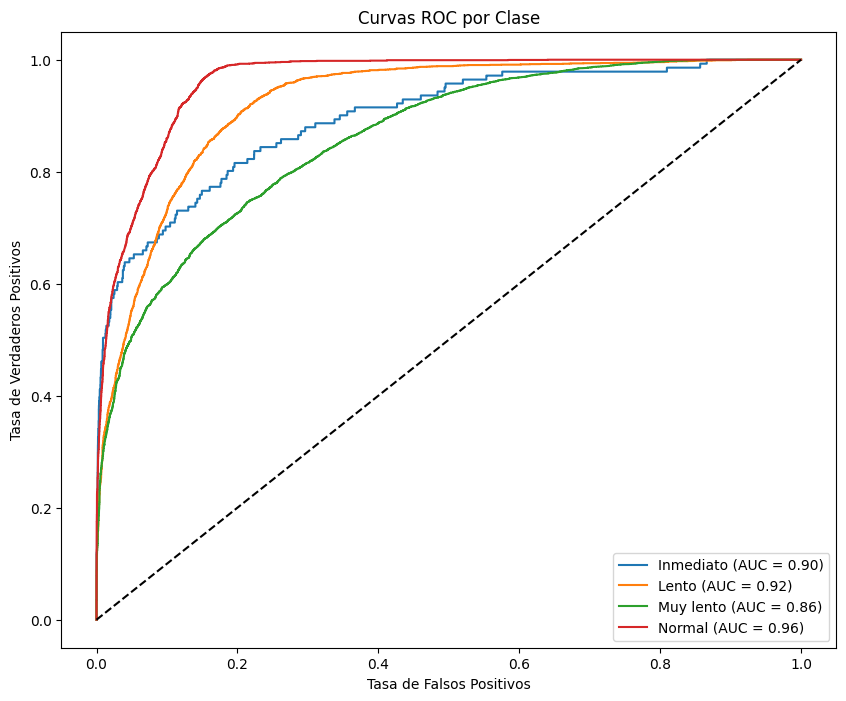

In [ ]:
# Calcular curva ROC para cada clase
plt.figure(figsize=(10,8))
for i in range(len(best_rf.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{best_rf.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por Clase')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# 4. Guardar modelo final (para producción)
import joblib
import datetime

model_metadata = {
    'fecha_entrenamiento': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'accuracy': 0.74,
    'classes': list(best_rf.classes_),
    'features': features
}

joblib.dump({
    'model': best_rf,
    'metadata': model_metadata,
    'scaler': scaler,
    'encoder': le
}, 'modelo_final.pkl')

print("\n✅ Modelo entrenado y guardado correctamente como 'modelo_final.pkl'")


✅ Modelo entrenado y guardado correctamente como 'modelo_final.pkl'


In [1]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Aplicar pesos de clase
sample_weights = compute_sample_weight('balanced', y_train_bal)
best_rf.fit(X_train_bal, y_train_bal, sample_weight=sample_weights)


NameError: name 'y_train_bal' is not defined

In [ ]:
# 2. Umbral de decisión ajustado (para aumentar precision)
from sklearn.metrics import precision_recall_curve

# Calcular umbral óptimo para clase "Inmediato"
immediate_class_idx = list(best_rf.classes_).index('Inmediato')
precisions, recalls, thresholds = precision_recall_curve(
    y_test_bin[:, immediate_class_idx],
    y_pred_prob[:, immediate_class_idx]
)

# Encontrar umbral que de al menos 50% precision
threshold_50p = thresholds[np.argmax(precisions >= 0.5)]
print(f"\nUmbral recomendado para clase Inmediato: {threshold_50p:.2f}")


Umbral recomendado para clase Inmediato: 0.69


In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_recall_curve

class ImprovedRandomForest(BaseEstimator, ClassifierMixin):
    def __init__(self, rf_model, target_precision=0.5, target_class='Inmediato'):
        self.rf_model = rf_model
        self.target_precision = target_precision
        self.target_class = target_class
        self.threshold_ = None
        self.classes_ = None

    def fit(self, X, y):
        # Calcular pesos de clase
        sample_weights = compute_sample_weight('balanced', y)
        self.rf_model.fit(X, y, sample_weight=sample_weights)

        # Guardar clases
        self.classes_ = self.rf_model.classes_

        # Predecir probabilidades en los datos de entrenamiento
        y_pred_prob = self.rf_model.predict_proba(X)

        # Encontrar el índice de la clase objetivo
        target_class_idx = list(self.classes_).index(self.target_class)

        # Calcular umbral óptimo
        precisions, recalls, thresholds = precision_recall_curve(
            (y == self.target_class).astype(int),
            y_pred_prob[:, target_class_idx]
        )

        # Encontrar el primer umbral que alcanza la precisión objetivo
        if any(precisions >= self.target_precision):
            self.threshold_ = thresholds[np.argmax(precisions >= self.target_precision)]
        else:
            self.threshold_ = 0.5  # Valor por defecto si no se alcanza la precisión

        return self

    def predict(self, X):
        # Predecir probabilidades
        y_pred_prob = self.rf_model.predict_proba(X)

        # Encontrar el índice de la clase objetivo
        target_class_idx = list(self.classes_).index(self.target_class)

        # Crear predicciones basadas en el umbral
        preds = self.rf_model.predict(X)
        preds[(y_pred_prob[:, target_class_idx] >= self.threshold_)] = self.target_class

        return preds

    def predict_proba(self, X):
        return self.rf_model.predict_proba(X)

    def get_params(self, deep=True):
        return self.rf_model.get_params(deep)

    def set_params(self, **params):
        return self.rf_model.set_params(**params)

In [ ]:
# 1. Crear tu modelo RandomForest original
from sklearn.ensemble import RandomForestClassifier

# Definir the best_params dictionary with the desired hyperparameters
best_params = {
    'n_estimators': 150,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt', # Changed from 'auto' to 'sqrt' as 'auto' is deprecated in favor of 'sqrt' or 'log2'
    'random_state': 42,
    'n_jobs': -1
}

rf = RandomForestClassifier(**best_params)  # usa los mejores parámetros

# 2. Crear la versión mejorada
improved_rf = ImprovedRandomForest(rf, target_precision=0.5, target_class='Inmediato')

# 3. Entrenar con los datos
improved_rf.fit(X_train_bal, y_train_bal)

# 4. Evaluar
y_pred_improved = improved_rf.predict(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
import joblib
joblib.dump(improved_rf, 'random_forest_2.0.pkl')

['random_forest_2.0.pkl']